# Solving the Head and Neck Tumor Segmentation for MR-Guided Applications(HNTS-MRG) with UNETR

### Installing and setting up correct dependencies for the environment

In [2]:
%pip install -q "monai-weekly[nibabel, tqdm, einops]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import shutil
import tempfile
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np
import torch

import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm

from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.networks.nets import UNETR

from monai.data import (
    DataLoader,
    Dataset,
    CacheDataset,
    decollate_batch,
)

# print_config()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-04-03 13:45:22.464034: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-03 13:45:22.488434: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-03 13:45:22.878054: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find Tensor

### Setting up directories for training

Project is set up to access dataset stored at the Cybele lab at NTNU.

In [4]:
directory = "data_directory"
os.makedirs(directory, exist_ok=True)
root_dir = directory

# Define the correct training directory path
base_directory = "/datasets/tdt4265/mic/open/HNTS-MRG"

print(f"Base directory path: {base_directory}")
print(f"Base directory exists: {os.path.exists(base_directory)}")

Base directory path: /datasets/tdt4265/mic/open/HNTS-MRG
Base directory exists: True


### Hyperparameters

In [ ]:
# Training parameters
max_epochs = 20
batch_size = 1

# Data processing parameters
train_validation_split = 0.8
model_save_rate = 4 # How often the model is saved

# UNETR model parameters
patch_size=(64, 64, 32)
feature_size=16
hidden_size=768
mlp_dim=3072
num_heads=12
proj_type="perceptron"
norm_name="instance"
res_block=True
dropout_rate=0.0

# Optimizer parameters
lr=1e-4
weight_decay=1e-5

In [6]:
# Sort patients into a list in accending order
train_patients = sorted(glob(os.path.join(base_directory, "train", "[0-9]*")), key=lambda x: int(os.path.basename(x)))
test_patients = sorted(glob(os.path.join(base_directory, "test", "[0-9]*")), key=lambda x: int(os.path.basename(x)))

# Organize patients into dictionaries with image and corresponding label for each patient
train_files = []
for patient in train_patients:
    train_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})
test_files = []
for patient in test_patients:
    test_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})

# Split training into train and validation data
train_files, val_files = train_test_split(train_files, train_size=train_validation_split)

### Inspect images

Inspecting images to determine intensity values of the T2-weighted scans as these are not standardized in MR-scans.

In [ ]:
samples = glob(os.path.join(base_directory, "train", "[0-9]*", "preRT", "[0-9]*_preRT_T2.nii.gz"))

min_intensities = []
max_intensities = []
mean_intensities = []
std_intensities = []
p1_intensities = []
p99_intensities = []

for sample in samples:
    img = nib.load(sample)
    data = img.get_fdata()

    min_intensities.append(data.min())
    max_intensities.append(data.max())
    mean_intensities.append(data.mean())
    std_intensities.append(data.std())
    p1_intensities.append(np.percentile(data, 1))
    p99_intensities.append(np.percentile(data, 99))

print(max(p99_intensities))
print(min(p1_intensities))

Using 1st and 99th percentiles to accurately capture intensities while also eliminating outliers from faulty scans.

### Transforms

Defining transformations for train, validation and test datasets.
The random transformations are only applied to the training data.

In [7]:
# Initial transforms for training, validation and testing datasets
pre_cache_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys="image", a_min=0.0, a_max=2572.0, b_min=0.0, b_max=1.0, clip=True), #Using values found above
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Random data augmentation for train dataset
post_cache_train_transforms = Compose([
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=patch_size, pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.50)
])

/home/hermaos/.local/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


### Set up cache and dataloader

In [8]:
train_cache = CacheDataset(
    data=train_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #24 threads available on Cybele computers
)

val_cache = CacheDataset(
    data=val_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18,
)

test_cache = CacheDataset(
    data=test_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #Caching between train, val  and test is done in series, not at the same time
)

# Apply random transformations at access time only to training data
random_train_cache = Dataset(
    data=train_cache,
    transform=post_cache_train_transforms
)

train_loader = DataLoader(
    dataset=random_train_cache,
    batch_size=batch_size,
    shuffle=True,
    num_workers=18,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_cache,
    batch_size=batch_size,
    shuffle=False,
    num_workers=18,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_cache,
    batch_size=batch_size,
    shuffle=False,
    num_workers=18,
    pin_memory=True
)


Loading dataset: 100%|██████████| 20/20 [00:05<00:00,  3.43it/s]


### Checking transformations and dataloader by visualizing an image

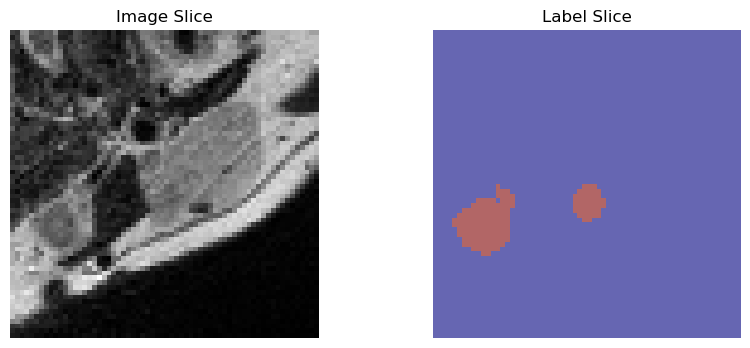

In [ ]:
# Get a single scan after transformations
scan = next(iter(train_loader))

# Access image and label in scan
image = scan["image"]  # Shape: [B, C, H, W, D] for 3D images
label = scan["label"]  # Same shape as image, or [B, 1, H, W, D] if single-channel

# [B, C, H, W, D] → [H, W, D]
image_np = image[0][0].detach().cpu().numpy()
label_np = label[0][0].detach().cpu().numpy()

# Pick a central slice
slice_id = image_np.shape[2] // 2
image_slice = image_np[:, :, slice_id]
label_slice = label_np[:, :, slice_id]

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_slice, cmap="gray")
plt.title("Image Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label_slice, cmap="jet", alpha=0.6)
plt.title("Label Slice")
plt.axis("off")
plt.show()

### Defining model, optimizer and loss function

In [10]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNETR(
    in_channels=1,
    out_channels=3,
    img_size=patch_size,
    feature_size=feature_size,
    hidden_size=hidden_size,
    mlp_dim=mlp_dim,
    num_heads=num_heads,
    proj_type=proj_type,
    norm_name=norm_name,
    res_block=res_block,
    dropout_rate=dropout_rate,
).to(device)

# Using Dice with Cross Entropy Loss for training
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
torch.backends.cudnn.benchmark = True
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

### Setting up training and validation methods

In [13]:
post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
# Using regular Dice for validation
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

total_batch_step_count = 0
epoch_count = 0

best_batch_step_count = 0
dice_val_best = 0.0

# Training loss
epoch_loss_values = []
# Validation DICE score, used as performance metric
mean_val_dice_scores = []

def train(train_loader, total_batch_step_count, best_batch_step_count, epoch_count, best_val_dice_score):
    model.train()
    epoch_iterator_train = tqdm(train_loader, dynamic_ncols=True)

    epoch_count += 1
    print(epoch_count)
    epoch_loss = 0

    # Iterates through all batches in 1 epoch (104)
    for step, batch in enumerate(epoch_iterator_train):
        image, label = (batch["image"].cuda(), batch["label"].cuda())
        pred = model(image) # Inference
        loss = loss_function(pred, label)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        total_batch_step_count += 1

    avg_epoch_loss = epoch_loss / len(train_loader)
    epoch_loss_values.append(avg_epoch_loss)

    # Running validation after each epoch
    mean_val_dice_score = validate(val_loader)
    mean_val_dice_scores.append(mean_val_dice_score)
    
    if mean_val_dice_score > best_val_dice_score:
        best_val_dice_score = mean_val_dice_score
        best_batch_step_count = total_batch_step_count
        print("Improvement! Current Best Avg. Dice: {} Current Avg. Dice: {}".format(best_val_dice_score, mean_val_dice_score))
        # Only save some models to save on I/O computation time
        if epoch_count % model_save_rate == 0 or epoch_count == max_epochs:
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("Model Was Saved!")
    else:
        print("No improvement. Current Best Avg. Dice: {} Current Avg. Dice: {}".format(best_val_dice_score, mean_val_dice_score))

    return total_batch_step_count, best_batch_step_count, epoch_count, best_val_dice_score

def validate(epoch_iterator_val):
    model.eval()
    with torch.no_grad():
        # Iterates through all batches in 1 epoch (26)
        for step, batch in enumerate(epoch_iterator_val):
            image_val, label_val = (batch["image"].cuda(), batch["label"].cuda())
            outputs_val = sliding_window_inference(image_val, patch_size, 4, model) # Inference

            labels_val_list = decollate_batch(label_val)
            outputs_val_list = decollate_batch(outputs_val)
            labels_val_convert = [post_label(val_label_tensor) for val_label_tensor in labels_val_list]
            outputs_val_convert = [post_pred(val_pred_tensor) for val_pred_tensor in outputs_val_list]

            dice_metric(y_pred=outputs_val_convert, y=labels_val_convert)
        mean_dice_val = dice_metric.aggregate().item()
        dice_metric.reset()
    return mean_dice_val

# Main training loop
for i in range(max_epochs):
    total_batch_step_count, best_batch_step_count, epoch_count, dice_val_best = train(train_loader, total_batch_step_count, best_batch_step_count, epoch_count, dice_val_best)


1








































  0%|          | 0/20 [00:39<?, ?it/s]


Improvement! Current Best Avg. Dice: 0.09166935831308365 Current Avg. Dice: 0.09166935831308365


  0%|          | 0/104 [00:00<?, ?it/s]

2


...

No improvement. Current Best Avg. Dice: 0.12773452699184418 Current Avg. Dice: 0.11007164418697357


  0%|          | 0/104 [00:00<?, ?it/s]

20


100%|██████████| 104/104 [00:06<00:00, 15.99it/s]


Improvement! Current Best Avg. Dice: 0.12943428754806519 Current Avg. Dice: 0.12943428754806519
Model Was Saved!


### Plotting Loss and Dice

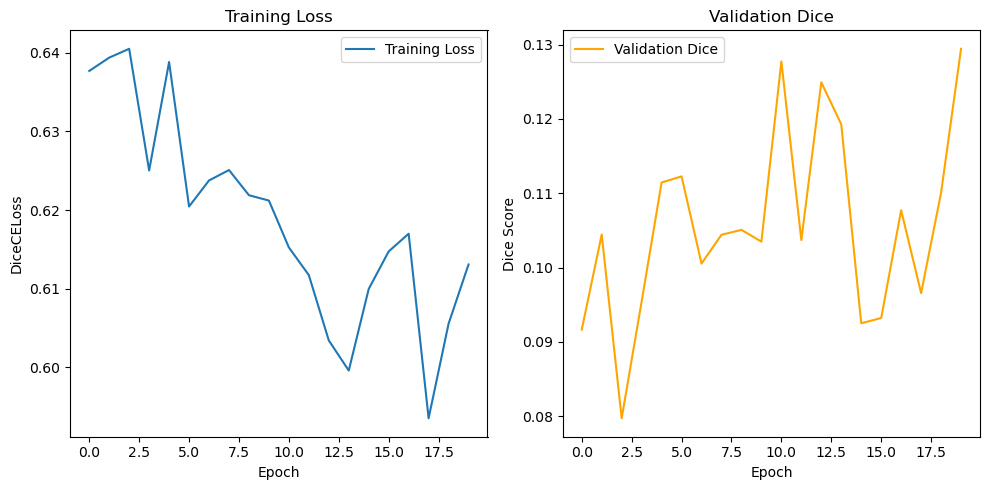

In [14]:
# Plotting average loss over all batches for each epoch
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss_values, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("DiceCELoss")
plt.title("Training Loss")
plt.legend()

# Plotting validation DICE-values for each epoch
plt.subplot(1, 2, 2)
plt.plot(mean_val_dice_scores, label="Validation Dice", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice")
plt.legend()

plt.tight_layout()
plt.show()

### Testing best model by visualizing scan, label and prediction

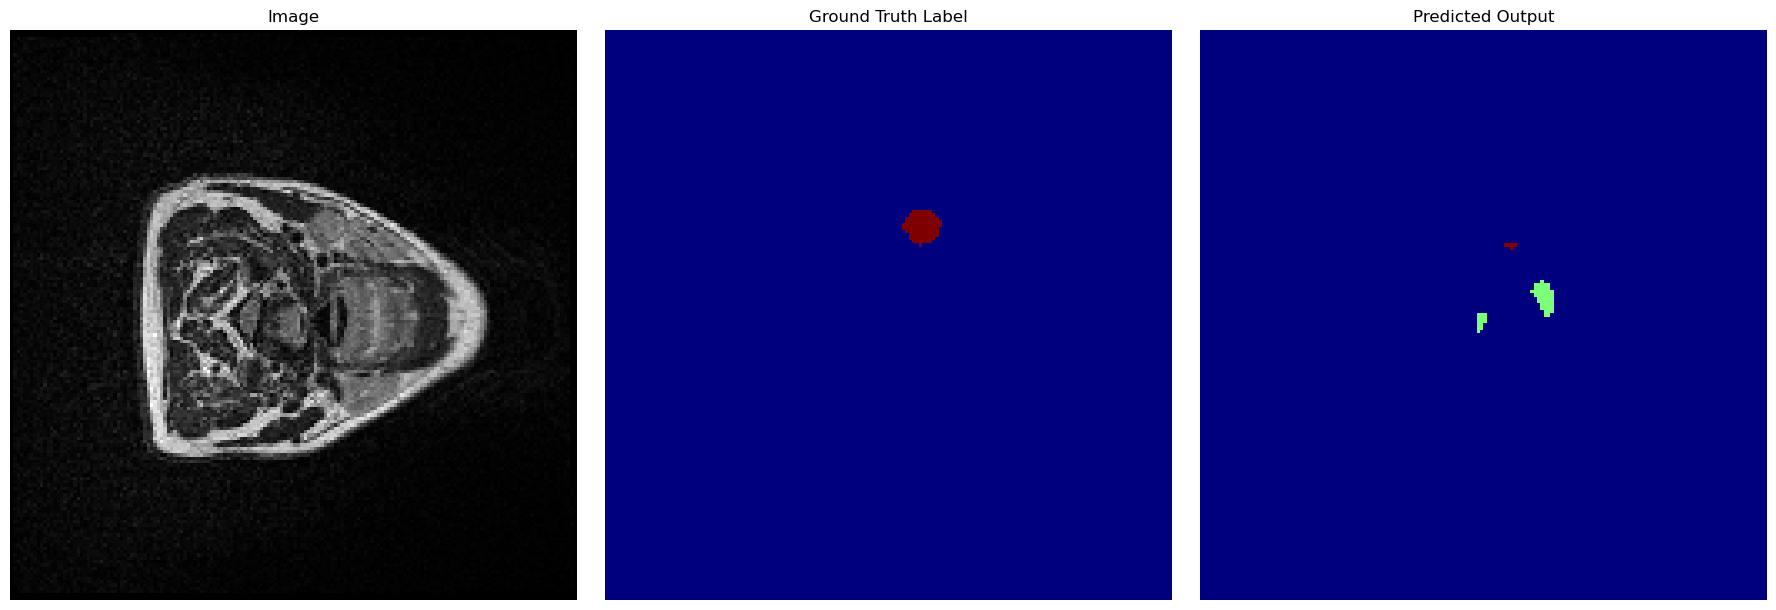

0.18042564392089844


In [ ]:
# Choose patient between 1-25
case_num = 25

post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)

# Load best model parameters
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

for id, batch in enumerate(val_loader):
    if id == case_num:
        val_input, label_input = (batch["image"].cuda(), batch["label"].cuda())
        img_name = os.path.split(batch["image"].meta["filename_or_obj"][0])[1]

        with torch.no_grad():
            val_outputs = sliding_window_inference(val_input, patch_size, 4, model)
        
        # Post-process the outputs and labels
        labels_list = decollate_batch(label_input)
        outputs_list = decollate_batch(val_outputs)
        labels_convert = [post_label(label_tensor) for label_tensor in labels_list]
        outputs_convert = [post_pred(output_tensor) for output_tensor in outputs_list]

        # Convert to numpy for visualization
        val_inputs_np = val_input.cpu().numpy()
        val_labels_np = labels_convert[0].cpu().numpy()
        val_outputs_np = outputs_convert[0].cpu().numpy()

        # Select a slice for visualization (e.g., middle slice along z-axis)
        z_dim = val_inputs_np.shape[-1]  # Depth
        slice_id = z_dim // 2

        # Plot the image, label, and prediction
        plt.figure("Validation Case", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title("Image")
        plt.imshow(val_inputs_np[0, 0, :, :, slice_id], cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Ground Truth Label")
        plt.imshow(val_labels_np.argmax(axis=0)[:, :, slice_id], cmap="jet")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Predicted Output")
        plt.imshow(val_outputs_np.argmax(axis=0)[:, :, slice_id], cmap="jet")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        dice_metric(y_pred=outputs_convert, y=labels_convert)
        print(dice_metric.aggregate().item())
        break

### Applying model on test data

In [ ]:
post_label = AsDiscrete(to_onehot=3)
post_pred = AsDiscrete(argmax=True, to_onehot=3)
# Using regular Dice for testing
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

def test(test_loader):
    model.eval()
    mean_test_dice_scores = []
    epoch_iterator_test = tqdm(test_loader, dynamic_ncols=True)

    with torch.no_grad():
        for step, batch in enumerate(epoch_iterator_test):
            image_test, label_test = (batch["image"].cuda(), batch["label"].cuda())

            outputs_test = sliding_window_inference(image_test, patch_size, 4, model) # Inference

            labels_test_list = decollate_batch(label_test)
            outputs_test_list = decollate_batch(outputs_test)
            labels_test_convert = [post_label(label_tensor) for label_tensor in labels_test_list]
            outputs_test_convert = [post_pred(output_tensor) for output_tensor in outputs_test_list]

            dice_metric(y_pred=outputs_test_convert, y=labels_test_convert)
            mean_dice_test = dice_metric.aggregate().item()
            mean_test_dice_scores.append(mean_dice_test)
            dice_metric.reset()
    
    mean_test_dice = sum(mean_test_dice_scores) / len(mean_test_dice_scores)
    print(f"Mean Test Dice: {mean_test_dice}")

    return mean_test_dice, mean_test_dice_scores


# Load best model parameters
model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))

mean_test_dice, mean_test_dice_scores = test(test_loader)












100%|██████████| 20/20 [00:02<00:00,  7.36it/s]

Mean Test Dice: 0.14486854714341463
Per-sample Dice Scores: [0.28125, 0.11481332778930664, 0.0, 0.1016337051987648, 0.21504729986190796, 0.27862873673439026, 0.07883099466562271, 0.3190095126628876, 0.07673231512308121, 0.2071627676486969, 0.11211644858121872, 0.16797417402267456, 0.016221612691879272, 0.1173495203256607, 0.07849042117595673, 0.17203742265701294, 0.014887244440615177, 0.09236355870962143, 0.23583921790122986, 0.2169826626777649]
